In [ ]:
import os
import cv2
import torch
import numpy as np
import torch.nn.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


In [ ]:
def visualize_gradcam_backbone(image_tensor, target_layer, device, title="Grad-CAM Backbone"):
    """
    Grad-CAM สำหรับ FasterRCNN backbone
    ใช้ feature map ของ backbone โดยตรง
    """
    rgb_img = image_tensor.permute(1,2,0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # hook เก็บ feature map
    activations = []
    def forward_hook(module, inp, out):
        activations.append(out)
    handle = target_layer.register_forward_hook(forward_hook)

    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    feature_map = activations[0][0].cpu().numpy()  # [C,H_feat,W_feat]
    cam = feature_map.mean(axis=0)  # [H_feat, W_feat]

    # resize CAM ให้ตรงกับภาพ
    cam = cv2.resize(cam, (rgb_img.shape[1], rgb_img.shape[0]))
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    visualization = show_cam_on_image(rgb_img, cam, use_rgb=True)
    return visualization


In [ ]:
best_checkpoint_path = "./best640.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 6)

checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

classes = ['bg', 'objects', '1', '10', '2', '5']

img1 = Image.open("../test_images/test_1.jpg").convert("RGB")
img2 = Image.open("../test_images/test_6.jpg").convert("RGB")

transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])

In [ ]:
for name, module in model.backbone.body.named_modules():
    print(module)

IntermediateLayerGetter(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): FrozenBatchNorm2d(64, eps=1e-05)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): FrozenBatchNorm2d(64, eps=1e-05)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): FrozenBatchNorm2d(256, eps=1e-05)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(256, eps=1e-05)
      )
    )
    (1): Bottleneck(
      (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=Fa

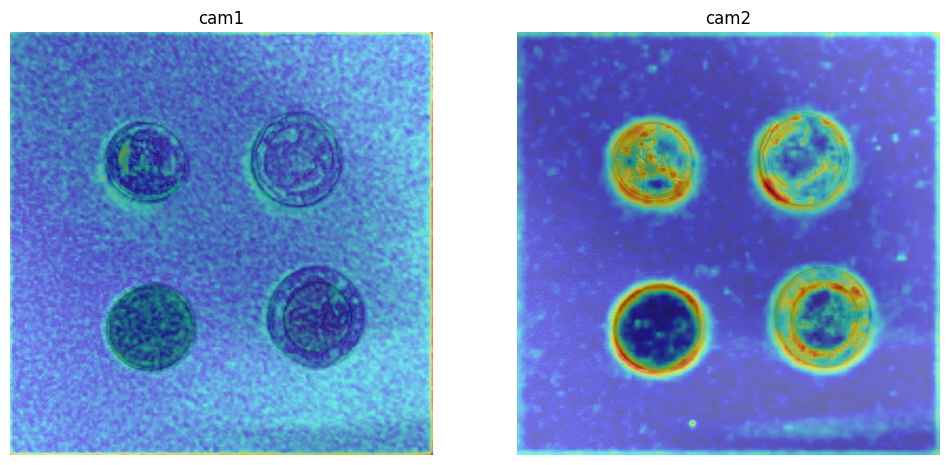

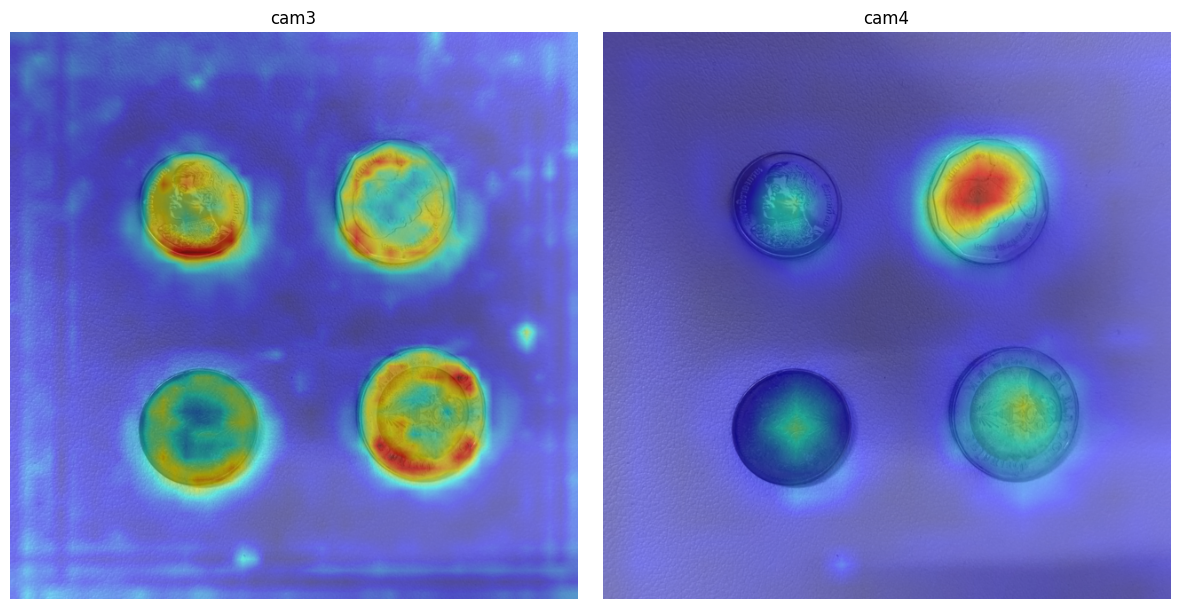

In [ ]:
target_layer = model.backbone.body.layer1[-1] 
cam1 = visualize_gradcam_backbone(transform(img1), target_layer, device, title="Grad-CAM")
target_layer = model.backbone.body.layer2[-1] 
cam2 = visualize_gradcam_backbone(transform(img1), target_layer, device, title="Grad-CAM")
target_layer = model.backbone.body.layer3[-1] 
cam3 = visualize_gradcam_backbone(transform(img1), target_layer, device, title="Grad-CAM")
target_layer = model.backbone.body.layer4[-1] 
cam4 = visualize_gradcam_backbone(transform(img1), target_layer, device, title="Grad-CAM")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cam1)
plt.title("cam1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cam2)
plt.title("cam2")
plt.axis("off")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cam3)
plt.title("cam3")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cam4)
plt.title("cam4")
plt.axis("off")

plt.tight_layout()
plt.show()